In [1]:
from safetensors.torch import load_file
import matplotlib.pyplot as plt
import seaborn as sns
device='cpu'
sns.set_theme()

In [ ]:
num_epochs = 5
state_fns = [f'../checkpoints/steering-save-projector/checkpoint-{468 * num}/adapter_model.safetensors' for num in range(1, num_epochs+1)]
projector_weights = []
for state in state_fns:
    state_dict = load_file(state)
    projector_weights.append(state_dict['base_model.model.projector.weight'])
diff_norms = [(projector_weights[i+1] - projector_weights[i]).norm(p='fro').item() for i in range(len(projector_weights)-1)]

plt.plot(range(2, num_epochs+1), diff_norms)
plt.xlabel('Epoch')
plt.ylabel('Frobenius Norm')
plt.title('Convergence of projection matrix during training')

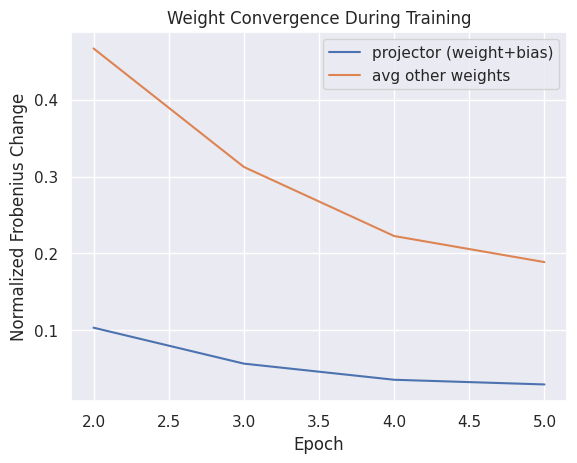

In [4]:
import torch
from safetensors.torch import load_file
import matplotlib.pyplot as plt

num_epochs = 5
state_fns = [f'../checkpoints/steering-save-projector/checkpoint-{468*num}/adapter_model.safetensors'
             for num in range(1, num_epochs+1)]

states = [load_file(fn) for fn in state_fns]

proj_diffs = []
other_diffs = []

for i in range(len(states)-1):
    s0, s1 = states[i], states[i+1]

    # projector weight + bias
    p_keys = [
        "base_model.model.projector.weight",
        "base_model.model.projector.bias",
    ]

    p_vals = []
    for k in p_keys:
        w0, w1 = s0[k], s1[k]
        p_vals.append(((w1 - w0).norm('fro') / (w0.norm('fro') + 1e-12)).item())

    proj_diffs.append(sum(p_vals) / len(p_vals))

    # all other weights
    vals = []
    for k in s0:
        if k in p_keys:
            continue
        w0, w1 = s0[k], s1[k]
        vals.append(((w1 - w0).norm('fro') / (w0.norm('fro') + 1e-12)).item())

    other_diffs.append(sum(vals) / len(vals))

epochs = range(2, num_epochs+1)

plt.plot(epochs, proj_diffs, label="projector (weight+bias)")
plt.plot(epochs, other_diffs, label="avg other weights")
plt.xlabel("Epoch")
plt.ylabel("Normalized Frobenius Change")
plt.title("Weight Convergence During Training")
plt.legend()
plt.show()